In [1]:
from COSMOtherm.outputfile_ingestion import list_files_with_extension, get_output_df
from COSMOtherm.Configfiles import COSMOthermConfig as COSMOConfig
from COSMOtherm.Configfiles import Config
from COSMOtherm.funcs import load_and_sort_solvents, build_design_matrix_fullfactorial

solvents = load_and_sort_solvents(Config.solvents_fullpath)
filelist = list_files_with_extension(folder_path=COSMOConfig.odir, file_extension="tab")

In [2]:
output_data = get_output_df(files=filelist)


solvents["index"] = solvents.index

output_data = output_data.merge(solvents[['COSMO_name','index']], left_on='Compound 2', right_on='COSMO_name', how='left')


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Extract unique ranges
temperature_range = output_data['Temperature (°C)'].unique().tolist()
lactic_acid_range = output_data["Phase 1 x(3) input"].unique().tolist()
solvent_indices = output_data.sort_values(by=["index"])["index"].unique().tolist()

print(f"Temperature range: {temperature_range}")
print(f"Lactic acid range: {lactic_acid_range}")

# Create a list of DataFrames for each lactic acid value
data_by_lactic_acid = []
for la_val in lactic_acid_range:
    filtered_data = output_data[output_data["Phase 1 x(3) input"] == la_val]
    filtered_data = filtered_data.sort_values(by=["index", "Temperature (°C)"]).reset_index(drop=True)
    data_by_lactic_acid.append(filtered_data)


# Create a meshgrid for temperature and solvent indices
temperature = np.array(temperature_range)
solvent_indices_array = np.array(solvent_indices)
X, Y = np.meshgrid(temperature, solvent_indices_array)

# Prepare Z values (Phase 2 x(3) output / Phase 1 x(3) output)
KV_values = []
x_la_org_values = []
for la_value in lactic_acid_range:
    x_la_org = np.zeros_like(X, dtype=float)
    KV = np.zeros_like(X, dtype=float)
    for i, temp in enumerate(temperature):
        for j, solvent_idx in enumerate(solvent_indices):
            filtered_data = output_data[(output_data["index"] == solvent_idx) & (output_data["Temperature (°C)"] == temp) & (output_data["Phase 1 x(3) input"] == la_value)]
            if not filtered_data.empty:
                x_la_org[j, i] = filtered_data["Phase 2 x(3) output"].values[0] / filtered_data["Phase 1 x(3) output"].values[0]
                KV[j, i] = filtered_data["Phase 2 x(3) output"].values[0]
    x_la_org_values.append(x_la_org)
    KV_values.append(KV)

: 

C:\Users\stto01\AppData\Local\Temp\262\ipykernel_128252\3970967941.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), rotation=45, ha='right')  # Rotate x-axis labels for better visibility
C:\Users\stto01\AppData\Local\Temp\262\ipykernel_128252\3970967941.py:36: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


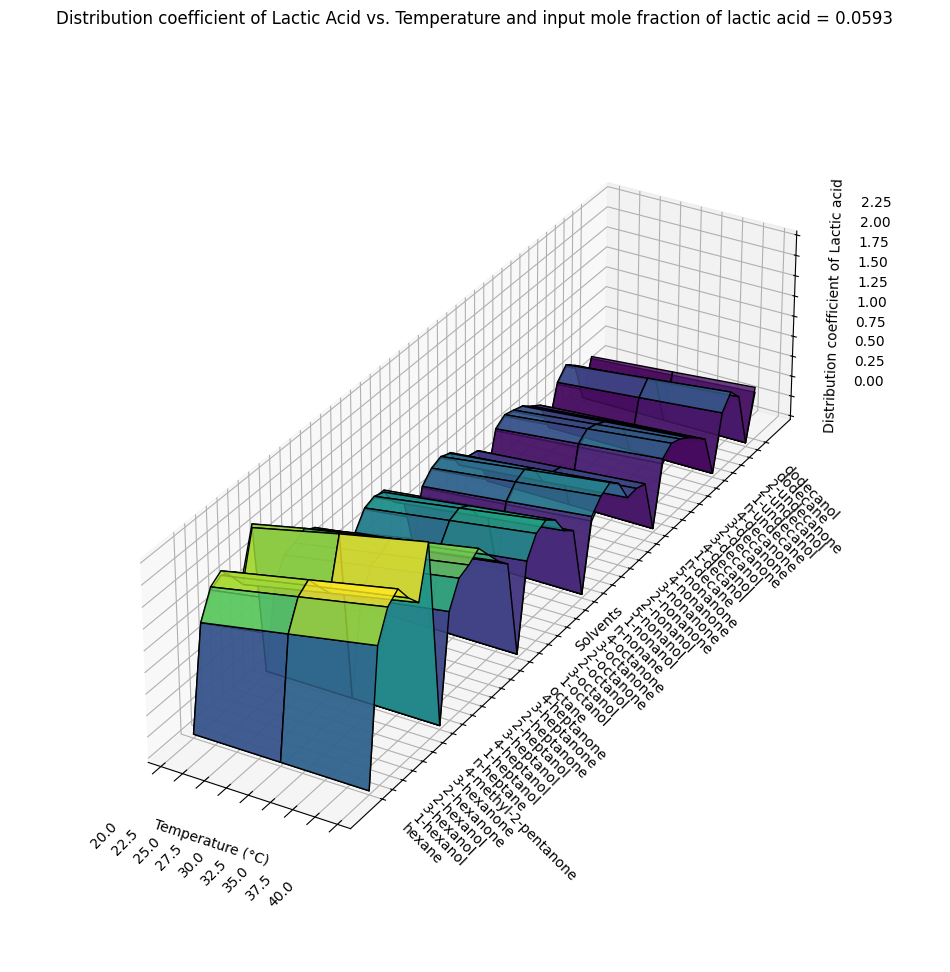

: 

In [ ]:
%matplotlib inline

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Adjust the figure size to stretch in the y-direction
fig = plt.figure(figsize=(12, 16))  # Increase the height to stretch the plot
ax = fig.add_subplot(111, projection='3d')

# Keep the axis projection as is
# ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), np.diag([1, 2, 1, 1]))

ax.set_box_aspect([0.25, 1, 0.25])  # Equal aspect ratio for x, y, z

# Plot the surface
surf_1 = ax.plot_surface(X, Y, KV_values[0], cmap='viridis', edgecolor='k', alpha=0.8)
surf_2 = ax.plot_surface(X, Y, KV_values[-1], cmap='viridis', edgecolor='k', alpha=0.8)

# Replace solvent indices with COSMO_name values for y-axis labels
y_labels = [solvents.loc[solvents['index'] == idx, 'COSMO_name'].values[0] for idx in solvent_indices_array]
ax.set_yticks(solvent_indices_array)
ax.set_yticklabels(y_labels, rotation=-45, ha='left')

ax.set_xticklabels(ax.get_xticks(), rotation=45, ha='right')  # Rotate x-axis labels for better visibility
ax.tick_params(axis='z', pad=40)  # Increase the padding for y-axis labels
ax.tick_params(axis='y', pad=20)  # Increase the padding for y-axis labels
ax.tick_params(axis='x', pad=20)  # Increase the padding for x-axis labels
#ax.rotate_view = -45  # Set the initial rotation angle
# Add labels and color bar
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Solvents")
ax.set_zlabel("Distribution coefficient of Lactic acid")
ax.set_title(f"Distribution coefficient of Lactic Acid vs. Temperature and input mole fraction of lactic acid = {lactic_acid_range[-1]}")

# fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.tight_layout()


In [ ]:
%matplotlib inline

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Adjust the figure size to stretch in the y-direction
fig = plt.figure(figsize=(12, 16))  # Increase the height to stretch the plot
ax = fig.add_subplot(111, projection='3d')

# Keep the axis projection as is
# ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), np.diag([1, 2, 1, 1]))

ax.set_box_aspect([0.25, 1, 0.25])  # Equal aspect ratio for x, y, z

# Plot the surface
surf_1 = ax.plot_surface(X, Y, x_la_org_values[0], cmap='viridis', edgecolor='k', alpha=0.8)
surf_2 = ax.plot_surface(X, Y, x_la_org_values[-1], cmap='viridis', edgecolor='k', alpha=0.8)

# Replace solvent indices with COSMO_name values for y-axis labels
y_labels = [solvents.loc[solvents['index'] == idx, 'COSMO_name'].values[0] for idx in solvent_indices_array]
ax.set_yticks(solvent_indices_array)
ax.set_yticklabels(y_labels, rotation=-45, ha='left')

ax.set_xticklabels(ax.get_xticks(), rotation=45, ha='right')  # Rotate x-axis labels for better visibility
ax.tick_params(axis='z', pad=40)  # Increase the padding for y-axis labels
ax.tick_params(axis='y', pad=20)  # Increase the padding for y-axis labels
ax.tick_params(axis='x', pad=20)  # Increase the padding for x-axis labels
#ax.rotate_view = -45  # Set the initial rotation angle
# Add labels and color bar
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Solvents")
ax.set_zlabel("Distribution coefficient of Lactic acid")
ax.set_title(f"Distribution coefficient of Lactic Acid vs. Temperature and input mole fraction of lactic acid = {lactic_acid_range[-1]}")

# fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.tight_layout()


In [4]:
fullfact = build_design_matrix_fullfactorial(
            tC_range=tC_range, 
            x1_lacticacid_range=x1_lacticacid_range, 
            solvents=solvents,
            )
        

In [ ]:
# Check if the output_data is complete:
len(fullfact)
len(output_data)

1032